In [1]:
# IMPORTS

import pandas as pd                     # dataframe functionality
import geopandas as gpd                 # geodataframe functionality

from pathlib import Path                # helps with Windows filepaths
from shapely.geometry import Point      # for buffer analysis
import matplotlib.pyplot as plt         # mapping

from itables import show                # quick table view

import contextily as cx                 # basemaps
from datetime import datetime           # for file timestamps

import numpy as np
from shapely.geometry import MultiPoint
from shapely.geometry import box
from matplotlib_scalebar.scalebar import ScaleBar



In [2]:
# --- Paths ---
DATA_ROOT = Path(r"C:\Users\orinj\Documents\Urban Planning\GIS Data")

paths = {
    "boroughs":         DATA_ROOT / "Borough Boundaries" / "geo_export_a539c2a7-d30a-4c26-9540-a9fb57bc35cf.shp",
    "building_footprints":       DATA_ROOT / "IBX" / "bk_qn_building_footprints.geojson",
    "subway_lines":     DATA_ROOT / "IBX" / "Subway Lines" / "geo_export_9137b667-8e18-40c5-9687-65c426cb6fcb.shp",
    "pavement_edge":    DATA_ROOT / "NYC Planimetric Database_ Pavement Edge_20251031" / "geo_export_636f5a0b-00ce-4659-a89e-be479aa02b6b.shp",
    "sidewalks":        DATA_ROOT / "NYC Planimetric Database_ Sidewalk_20251031" / "geo_export_d77bc740-0279-450a-a0b4-c73f8ece7a4a.shp",
    "pluto":            DATA_ROOT / "Pluto" / "MapPLUTO25v3.gdb",
    "streets":          DATA_ROOT / "DCM.gdb",
    "parks":            DATA_ROOT / "Parks Properties_20251104" / "geo_export_03be6ed9-5d8d-403e-b157-70947265fbde.shp",
}

In [ ]:
''' 
Establish map centerpoint and buffer range
'''

location_input = "40.64317496732342, -74.02370556494591"
mile = 5280

longitude = float(location_input.split(',')[1].strip())
latitude = float(location_input.split(',')[0].strip())

# Buffer distance in feet
buffer_ft = mile * .25

# Padding to show detail outside of circular buffer
padding = 1.5

# Best projected CRS for NYC is EPSG:2263 (NAD83 / New York Long Island (ftUS))
basemap_crs = 2263





layers = {}
# Create location layer
layers['location'] = gpd.GeoDataFrame(geometry=[Point(longitude, latitude)], crs="EPSG:4326").to_crs(basemap_crs)

# Create buffer
layers["location"]["buffer"] = layers["location"].geometry.buffer(buffer_ft)
layers["location"]["padded_buffer"] = layers["location"].geometry.buffer(buffer_ft * padding)

In [22]:
''' 
Read files into geopandas (this step can take a minute)
'''

buffer = layers["location"]["buffer"].iloc[0]


# Reads data into geopandas using buffer, accounting for variable CRS and layer specifications
def read_with_buffer(path, buffer, **kwargs):
    
    # Step 1: Read just the metadata to get the file's CRS (no features loaded)
    file_crs = gpd.read_file(path, rows=0, **kwargs).crs
    
    # Step 2: Reproject buffer from basemap CRS to match the file's CRS
    buffer_reprojected = gpd.GeoSeries([buffer], crs=basemap_crs).to_crs(file_crs).iloc[0]
    
    # Step 3: Read the file filtered by the reprojected buffer
    layer = gpd.read_file(path, bbox=buffer_reprojected, **kwargs)
    
    # # Step 4: Reproject the loaded layer back to basemap CRS
    # layer = layer.to_crs(basemap_crs)
    
    return layer

layers["boroughs"] = gpd.read_file(paths['boroughs'])
# layers["building_footprints"] = read_with_buffer(paths['building_footprints'], buffer)
layers["subway_lines"] = read_with_buffer(paths['subway_lines'], buffer)
layers["pavement_edge"] = read_with_buffer(paths['pavement_edge'], buffer)
layers["sidewalks"] = read_with_buffer(paths['sidewalks'], buffer)
layers["pluto"] = read_with_buffer(paths['pluto'], buffer, layer="MapPLUTO_25v3_clipped")
# layers["streets"] = read_with_buffer(paths['streets'], buffer, layer="DCM_StreetCenterLine")
layers["parks"] = read_with_buffer(paths['parks'], buffer)


In [23]:
''' 
Set all layers to the same CRS
'''

# Set each layer CRS to EPSG:2263
for layer_name in list(layers.keys()):
    layers[layer_name] = layers[layer_name].to_crs(basemap_crs)


In [24]:
''' 
Filter layers by location buffer
'''

for layer_name in list(layers.keys()):
    if layer_name == "location":
        continue
    layers[layer_name] = layers[layer_name][layers[layer_name].intersects(layers["location"]["padded_buffer"].iloc[0])]

In [25]:
print(layers['subway_lines']['name'].unique())

['N-R']


In [26]:
''' 
Set subway line colors
'''

# create color map to set color by value
subways_color_map = {
    "G": "lightgreen",
    "L": "lightgray",
    "S": "darkgray",
    "7": "purple",

    "J": "brown",
    "Z": "brown",
    "J-Z": "brown",

    "A": "blue",
    "C": "blue",
    "E": "blue",
    "A-C": "blue",
    "A-C-E": "blue",

    "B": "orange",
    "D": "orange",
    "F": "orange",
    "M": "orange",
    "B-D": "orange",
    "F-M": "orange",

    "N": "gold",
    "Q": "gold",
    "R": "gold",
    "W": "gold",
    "N-Q": "gold",
    "N-Q-R": "gold",
    "R-W": "gold",
    "N-W": "gold",
    "N-R-W": "gold",
    "N-R": "gold",
    "N-Q-R-W": "gold",

    "1": "red",
    "2": "red",
    "3": "red",
    "1-2": "red",
    "2-3": "red",
    "1-2-3": "red",

    "4": "green",
    "5": "green",
    "6": "green",
    "4-5": "green",
    "4-5-6": "green",

    "SIR": "lightblue",
}

# Map the column to the color map
layers['subway_lines']["color"] = layers['subway_lines']["name"].map(subways_color_map).fillna("gray")

In [27]:
'''
Add scale bar
'''
def add_scale_bar():
    scale = ScaleBar(
        dx=1/5280,
        units='mi',
        dimension='imperial-length',
        fixed_units='mi',   # specify units
        fixed_value=0.25,    # specify number of units to show
        location="lower left",
        color="black",
        box_color="none",
        box_alpha=0,  # box transparency
        font_properties={'family': 'Arial'}     # Set font
    )
    return scale

In [28]:
# Extract buffer geometry for extent
buffer = layers["location"]["buffer"].iloc[0]

print(buffer)

POLYGON ((978991.2987666727 173603.25185095903, 978984.94260588 173473.86922572402, 978965.935336805 173345.73262589774, 978934.4600098393 173220.07607698315, 978890.8197495877 173098.10972023712, 978835.4348356125 172981.0081583487, 978768.8386549121 172869.89914337316, 978691.6725651115 172765.85271586303, 978604.679717839 172669.8708997928, 978508.6979017687 172582.87805252022, 978404.6514742586 172505.71196271968, 978293.542459283 172439.1157820192, 978176.4408973947 172383.73086804413, 978054.4745406486 172340.09060779252, 977928.817991734 172308.61528082678, 977800.6813919077 172289.60801175173, 977671.2987666727 172283.25185095903, 977541.9161414377 172289.60801175173, 977413.7795416114 172308.61528082678, 977288.1229926968 172340.09060779252, 977166.1566359508 172383.73086804413, 977049.0550740624 172439.1157820192, 976937.9460590868 172505.71196271968, 976833.8996315767 172582.87805252022, 976737.9178155065 172669.8708997928, 976650.9249682339 172765.85271586303, 976573.758878

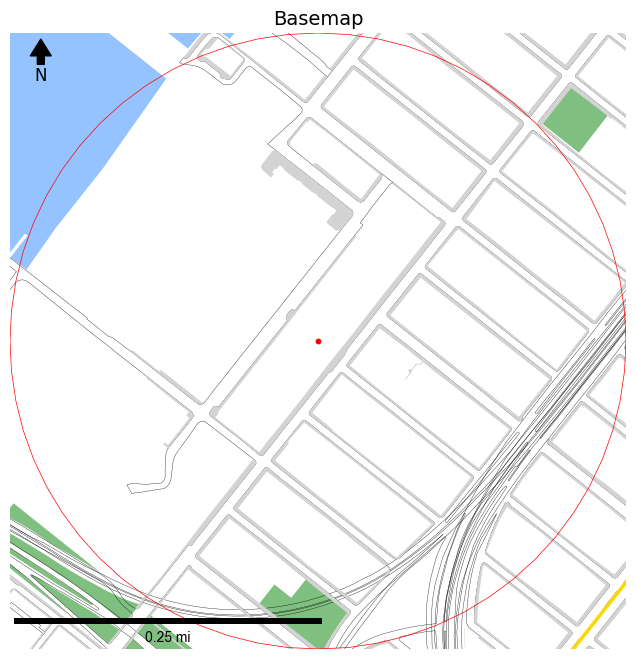

In [29]:
# Extract buffer geometry for extent
buffer = layers["location"]["buffer"].iloc[0]



# Get extent from buffer bounds
xmin, ymin, xmax, ymax = buffer.bounds

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Background rectangle (water)
ax.add_patch(
    plt.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        facecolor="#95c3ff",
        edgecolor="none",
        zorder=0
    )
)


layers["boroughs"].plot(ax=ax, color="white", edgecolor="none", linewidth=1, alpha=1, zorder=10)
layers["parks"].plot(ax=ax, color="green", edgecolor="none", alpha=0.5, zorder=20)

# layers["building_footprints"].plot(ax=ax, color="gray", edgecolor="black", alpha=0.5, zorder=21)


# layers["streets"].plot(ax=ax, color="gray", linewidth=0.5, zorder=30)
layers["pavement_edge"].plot(ax=ax, color="black", linewidth=0.25, zorder=31)
layers["sidewalks"].plot(ax=ax, color="lightgray", linewidth=0.25, zorder=32)

layers["subway_lines"].plot(ax=ax, color=layers['subway_lines']["color"], linewidth=2.5, zorder=40)
layers["location"].plot(ax=ax, color="red", markersize=10, alpha=1, zorder=50)

layers["location"]["buffer"].plot(ax=ax, color="none", edgecolor="red", linewidth=.5, alpha=1, zorder=50)


# Set extent
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Set title
ax.set_title(f"Basemap", fontsize=14)

# Remove axes for a cleaner look - .axis("off") does not work with facecolor
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

# --- NORTH ARROW ---
x, y, arrow_length = 0.05, .99, 0.06  # Position and size in axis fraction
ax.annotate('N',
    xy=(x, y),
    xytext=(x, y - arrow_length),
    arrowprops=dict(facecolor='black', width=5, headwidth=15),
    ha='center', va='center',
    fontsize=12,
    xycoords=ax.transAxes)

# --- SCALE BAR ---
scalebar = add_scale_bar()
ax.add_artist(scalebar)
scalebar.set_zorder(100)

plt.show()